## Group-11

### Team Memners

Tuo Yan

Prayusha Poudel

Dan Le


# Diabetes Big Data Pipeline: Spark + MongoDB

The dataset selected for this project is the Diabetes Healthcare Dataset, which contains medical information about patients such as age, BMI (Body Mass Index), blood glucose level, hypertension, and diabetes status.

This dataset is chosen because it is large, realistic, and contains important health-related features. It is suitable for Big Data analysis and helps us understand how different factors like age, BMI, and glucose level affect diabetes.

By analyzing this dataset, we can gain insights that may help improve decision-making in healthcare systems, especially in identifying high-risk patients.

## Section 1: Setup & Imports

In this step, we install and import all the necessary libraries required for this project.

In [1]:
# Install required packages
# Run this cell once, then restart the kernel before continuing
%pip install pyspark pymongo pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.4/455.4 MB 3.2 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.4/808.4 kB 14.7 MB/s eta 0:00:00a 0:00:01
  Using cached pandas-2.3.3-cp310-cp310-macosx_11_0_arm64.whl (10.8 MB)
  Using cached matplotlib-3.10.8-cp310-cp310-macosx_11_0_arm64.whl (8.1 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 7.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.0/203.0 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 6.2 MB/s eta 0:00:0000:01
  Using cached numpy-2.2.6-cp310-cp310-macosx_14_0_arm64.whl (5.3 MB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.0/349.0 kB 10.8 MB/s eta 0:00:00
  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl (253 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached fonttools-4.62.

## Section 2: Initialize SparkSession


In this step, we start Spark so that we can process large amounts of data.

We create a Spark session using SparkSession.builder.
appName() gives a name to our project
master("local[*]") allows Spark to use all available CPU cores
MongoDB configuration is added to connect Spark with MongoDB

The getOrCreate() function either creates a new Spark session or uses an existing one.

This step is important because Spark must be initialized before we can process or analyze the dataset.

In [2]:
# Create SparkSession with MongoDB connector
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("DiabetesBigDataPipeline") \
    .master("local[*]") \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.4.0") \
    .config("spark.mongodb.read.connection.uri", "mongodb://localhost:27017/diabetes_db.patients") \
    .config("spark.mongodb.write.connection.uri", "mongodb://localhost:27017/diabetes_db.patients") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

# Set log level to ERROR to reduce verbosity
spark.sparkContext.setLogLevel("ERROR")

print("SparkSession created successfully!")
print(f"Spark version: {spark.version}")

:: loading settings :: url = jar:file:/Users/dandev947366/Desktop/Diabetes-Big-Data-Pipeline/venv/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /Users/dandev947366/.ivy2.5.2/cache
The jars for the packages stored in: /Users/dandev947366/.ivy2.5.2/jars
org.mongodb.spark#mongo-spark-connector_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-37ab6cda-73e0-4791-bfed-56192506ea33;1.0
	confs: [default]
	found org.mongodb.spark#mongo-spark-connector_2.12;10.4.0 in central
	found org.mongodb#mongodb-driver-sync;5.1.4 in central
	[5.1.4] org.mongodb#mongodb-driver-sync;[5.1.1,5.1.99)
	found org.mongodb#bson;5.1.4 in central
	found org.mongodb#mongodb-driver-core;5.1.4 in central
	found org.mongodb#bson-record-codec;5.1.4 in central
downloading https://repo1.maven.org/maven2/org/mongodb/spark/mongo-spark-connector_2.12/10.4.0/mongo-spark-connector_2.12-10.4.0.jar ...
	[SU

SparkSession created successfully!
Spark version: 4.1.1


## Section 3: Ingest CSV Data into MongoDB

In this step, we load the dataset from a CSV file using Pandas.

After loading the dataset, we connect to MongoDB and store the data in a collection.

Before inserting the data, we remove any existing records using delete_many({}) to avoid duplicates.

Then, we convert the dataset into a list of dictionaries using to_dict(orient="records"), because MongoDB stores data in JSON-like format.

Finally, we insert the data into MongoDB using insert_many().

This step allows us to store the dataset in a database for further processing and analysis.

In [3]:
# Connect to local MongoDB
from pymongo import MongoClient
import pandas as pd
client = MongoClient("mongodb://localhost:27017/")
db = client["diabetes_db"]
collection = db["patients"]

# Load CSV with pandas
df_csv = pd.read_csv("diabetes_dataset.csv")
print(f"CSV loaded: {len(df_csv)} rows, {len(df_csv.columns)} columns")
print("Columns:", list(df_csv.columns))
df_csv.head()

CSV loaded: 100000 rows, 16 columns
Columns: ['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [5]:
# Insert into MongoDB
# Clear old data first to avoid duplicates on re-runs
collection.delete_many({})

# Convert to list of dicts and insert
records = df_csv.to_dict(orient="records")
collection.insert_many(records)

print(f"Successfully ingested {len(records)} records into MongoDB.")
print(f"Verification — documents in collection: {collection.count_documents({})}")

Successfully ingested 100000 records into MongoDB.
Verification — documents in collection: 100000


## Section 4: Read from MongoDB → Spark DataFrame



In this step, we move the data from MongoDB into Spark for analysis.

First, we fetch the data using PyMongo. Then, we remove the _id field because Spark cannot process MongoDB ObjectId.

After that, we convert the cleaned data into a Spark DataFrame.

We also use printSchema() and show() to understand the structure of the dataset and preview the data.

This step is important because Spark DataFrames allow us to perform large-scale data processing efficiently.

In [6]:
# Step 1: Fetch data from MongoDB using PyMongo
mongo_data = list(collection.find())

# Step 2: Remove the '_id' field — ObjectId cannot be serialized by Spark
mongo_data = [{k: v for k, v in doc.items() if k != "_id"} for doc in mongo_data]

print(f"Fetched {len(mongo_data)} documents from MongoDB")
print("Sample document keys:", list(mongo_data[0].keys()) if mongo_data else "No data")

Fetched 100000 documents from MongoDB
Sample document keys: ['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']


In [7]:
# Step 3: Create Spark DataFrame
# We let Spark infer the schema first to see what columns exist
df_raw = spark.createDataFrame(mongo_data)
df_raw.printSchema()
df_raw.show(3)

root
 |-- age: double (nullable = true)
 |-- blood_glucose_level: long (nullable = true)
 |-- bmi: double (nullable = true)
 |-- diabetes: long (nullable = true)
 |-- gender: string (nullable = true)
 |-- hbA1c_level: double (nullable = true)
 |-- heart_disease: long (nullable = true)
 |-- hypertension: long (nullable = true)
 |-- location: string (nullable = true)
 |-- race:AfricanAmerican: long (nullable = true)
 |-- race:Asian: long (nullable = true)
 |-- race:Caucasian: long (nullable = true)
 |-- race:Hispanic: long (nullable = true)
 |-- race:Other: long (nullable = true)
 |-- smoking_history: string (nullable = true)
 |-- year: long (nullable = true)



+----+-------------------+-----+--------+------+-----------+-------------+------------+--------+--------------------+----------+--------------+-------------+----------+---------------+----+
| age|blood_glucose_level|  bmi|diabetes|gender|hbA1c_level|heart_disease|hypertension|location|race:AfricanAmerican|race:Asian|race:Caucasian|race:Hispanic|race:Other|smoking_history|year|
+----+-------------------+-----+--------+------+-----------+-------------+------------+--------+--------------------+----------+--------------+-------------+----------+---------------+----+
|32.0|                100|27.32|       0|Female|        5.0|            0|           0| Alabama|                   0|         0|             0|            0|         1|          never|2020|
|29.0|                 90|19.95|       0|Female|        5.0|            0|           0| Alabama|                   0|         1|             0|            0|         0|          never|2015|
|18.0|                160|23.76|       0|  Male|  

Traceback (most recent call last):
  File "/Users/dandev947366/Desktop/Diabetes-Big-Data-Pipeline/venv/lib/python3.10/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
  File "/Users/dandev947366/Desktop/Diabetes-Big-Data-Pipeline/venv/lib/python3.10/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
BrokenPipeError: [Errno 32] Broken pipe


## Section 5: Data Cleaning

In this step, we clean the dataset to ensure accurate analysis.

First, we remove rows where important values like age and BMI are missing.

Then, we convert columns such as age, BMI, diabetes, and blood glucose level into appropriate data types.

We also cache the cleaned DataFrame to improve performance when running multiple operations.

Finally, we calculate basic statistics such as total number of patients and percentage of diabetic patients.

This step ensures that the dataset is clean and ready for further analysis.

In [ ]:
from pyspark.sql.functions import col
df_clean = df_raw \
    .filter(col("age").isNotNull()) \
    .filter(col("bmi").isNotNull()) \
    .withColumn("age", col("age").cast("int")) \
    .withColumn("bmi", col("bmi").cast("double")) \
    .withColumn("diabetes", col("diabetes").cast("int")) \
    .withColumn("blood_glucose_level", col("blood_glucose_level").cast("double"))

# Cache for performance
df_clean.cache()

# Stats
total = df_clean.count()
diabetic = df_clean.filter(col("diabetes") == 1).count()

percentage = (diabetic / total * 100) if total > 0 else 0

print(f"Total clean records : {total}")
print(f"Diabetic patients   : {diabetic}  ({percentage:.1f}%)")
print(f"Non-diabetic        : {total - diabetic}")

df_clean.printSchema()
df_clean.show(5)

Total clean records : 100000
Diabetic patients   : 8500  (8.5%)
Non-diabetic        : 91500
root
 |-- age: integer (nullable = true)
 |-- blood_glucose_level: double (nullable = true)
 |-- bmi: double (nullable = true)
 |-- diabetes: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- hbA1c_level: double (nullable = true)
 |-- heart_disease: long (nullable = true)
 |-- hypertension: long (nullable = true)
 |-- location: string (nullable = true)
 |-- race:AfricanAmerican: long (nullable = true)
 |-- race:Asian: long (nullable = true)
 |-- race:Caucasian: long (nullable = true)
 |-- race:Hispanic: long (nullable = true)
 |-- race:Other: long (nullable = true)
 |-- smoking_history: string (nullable = true)
 |-- year: long (nullable = true)

+---+-------------------+-----+--------+------+-----------+-------------+------------+--------+--------------------+----------+--------------+-------------+----------+---------------+----+
|age|blood_glucose_level|  bmi|diabetes|gender

## Section 6: Spark SQL Analysis



In this step, we perform analysis using Spark SQL.

First, we create a temporary view called "diabetes_data" using createOrReplaceTempView(). This allows us to run SQL queries on the dataset.

Using SQL makes it easier to analyze relationships between variables such as age, BMI, location, and diabetes status.

In [9]:
# Register as a temporary SQL view
df_clean.createOrReplaceTempView("diabetes_data")
print("Temporary view 'diabetes_data' registered.")

Temporary view 'diabetes_data' registered.


### Query 1: Diabetes Rate by Location

In this query, we analyze how diabetes is distributed across different locations.

We group the data by location and calculate:

Total number of patients
Average BMI
Percentage of diabetic patients

The results are sorted so that locations with higher diabetes rates appear first.

In [10]:
# Note: if your dataset does not have a 'location' column, replace with 'gender' or another column
sql_query = """
    SELECT
        location,
        COUNT(*)                    AS total_patients,
        ROUND(AVG(bmi), 2)          AS avg_bmi,
        ROUND(AVG(diabetes) * 100, 2) AS diabetes_percentage
    FROM diabetes_data
    GROUP BY location
    HAVING COUNT(*) > 100
    ORDER BY diabetes_percentage DESC
"""

analysis_results = spark.sql(sql_query)
print("=== Diabetes Rate by Location ===")
analysis_results.show(10)

=== Diabetes Rate by Location ===
+--------------+--------------+-------+-------------------+
|      location|total_patients|avg_bmi|diabetes_percentage|
+--------------+--------------+-------+-------------------+
|      Delaware|          2036|  27.57|               9.82|
|        Kansas|          2036|  27.42|               9.77|
|      Illinois|          2036|  27.44|               9.58|
|       Montana|          2033|  27.41|               9.54|
| West Virginia|          1132|   27.5|               9.45|
|Virgin Islands|           763|  27.78|               9.44|
|  Rhode Island|          2035|  27.24|               9.43|
|      Kentucky|          2038|  27.31|               9.42|
| United States|          1401|  27.26|               9.35|
|       Vermont|          1338|  27.23|               9.34|
+--------------+--------------+-------+-------------------+
only showing top 10 rows


##  Query 2: Age group breakdown

In this step, we divide patients into different age groups using a CASE statement.

We then calculate:

Total number of patients
Diabetes percentage
Average BMI

This helps us understand how diabetes risk varies across different age groups.

In [11]:

age_group_query = """
    SELECT
        CASE
            WHEN age < 30 THEN 'Under 30'
            WHEN age BETWEEN 30 AND 49 THEN '30-49'
            WHEN age BETWEEN 50 AND 64 THEN '50-64'
            ELSE '65+'
        END AS age_group,
        COUNT(*)                          AS total,
        ROUND(AVG(diabetes) * 100, 2)     AS diabetes_pct,
        ROUND(AVG(bmi), 2)                AS avg_bmi
    FROM diabetes_data
    GROUP BY age_group
    ORDER BY age_group
"""

age_results = spark.sql(age_group_query)
print("=== Diabetes Rate by Age Group ===")
age_results.show()

=== Diabetes Rate by Age Group ===
+---------+-----+------------+-------+
|age_group|total|diabetes_pct|avg_bmi|
+---------+-----+------------+-------+
|    30-49|27647|        5.19|  29.07|
|    50-64|21350|       14.02|   29.6|
|      65+|18568|       20.45|  28.16|
| Under 30|32435|        0.84|  23.85|
+---------+-----+------------+-------+



## Section 7: Window Function — Rank Patients by Glucose Level

In this step, we use a window function to rank patients based on blood glucose level.

We partition the data by gender and rank patients within each group.

Higher glucose levels are often associated with diabetes, so this helps identify high-risk individuals.

This method is useful for comparing patients within similar categories.

In [12]:

from pyspark.sql.window import Window
from pyspark.sql.functions import col, desc, rank
# Window function: rank patients by blood glucose level within each gender
window_spec = Window.partitionBy("gender").orderBy(desc("blood_glucose_level"))

df_ranked = df_clean.withColumn("rank", rank().over(window_spec))

print("=== Top 3 Patients with Highest Glucose Levels per Gender ===")
df_ranked \
    .filter(col("rank") <= 3) \
    .select("gender", "age", "blood_glucose_level", "bmi", "diabetes", "rank") \
    .orderBy("gender", "rank") \
    .show()

=== Top 3 Patients with Highest Glucose Levels per Gender ===
+------+---+-------------------+-----+--------+----+
|gender|age|blood_glucose_level|  bmi|diabetes|rank|
+------+---+-------------------+-----+--------+----+
|Female| 56|              300.0|37.49|       1|   1|
|Female| 80|              300.0|27.32|       1|   1|
|Female| 63|              300.0|26.67|       1|   1|
|Female| 47|              300.0|54.79|       1|   1|
|Female| 65|              300.0|33.72|       1|   1|
|Female| 80|              300.0|27.32|       1|   1|
|Female| 62|              300.0|29.33|       1|   1|
|Female| 63|              300.0|47.54|       1|   1|
|Female| 64|              300.0|43.26|       1|   1|
|Female| 72|              300.0|27.32|       1|   1|
|Female| 70|              300.0|27.63|       1|   1|
|Female| 71|              300.0|46.86|       1|   1|
|Female| 27|              300.0|31.16|       1|   1|
|Female| 80|              300.0|31.18|       1|   1|
|Female| 71|              300.0|28.67

## Section 8: MongoDB Index Benchmark

In this step, we measure how indexing improves query performance.

First, we run a query without an index and record the execution time.

Then, we create an index on the location field and run the same query again.

By comparing the execution times, we can clearly see how indexing improves query speed.

This demonstrates the importance of optimization in database systems.

In [13]:
import time
import pymongo
# Benchmark: query time without index
start = time.time()
result_no_index = list(collection.find({"location": "Alabama"}))
time_no_index = time.time() - start
print(f"Without index — rows: {len(result_no_index)}, time: {time_no_index:.4f}s")

# Create index on 'location'
collection.create_index([("location", pymongo.ASCENDING)])
print("Index created on 'location'.")

# Benchmark: query time with index
start = time.time()
result_with_index = list(collection.find({"location": "Alabama"}))
time_with_index = time.time() - start
print(f"With index    — rows: {len(result_with_index)}, time: {time_with_index:.4f}s")

if time_no_index > 0:
    speedup = time_no_index / max(time_with_index, 0.0001)
    print(f"Speedup: {speedup:.1f}x faster with index")

Without index — rows: 2036, time: 0.0428s
Index created on 'location'.
With index    — rows: 2036, time: 0.0160s
Speedup: 2.7x faster with index


## Section 9: Write Analysis Results Back to MongoDB

In this step, we store the results of our Spark SQL analysis back into MongoDB.

We convert the Spark DataFrame into a Pandas DataFrame, and then into a list of dictionaries.

After that, we insert the results into a new MongoDB collection.

This allows us to save processed data for future use or reporting

In [14]:
# Convert Spark results to Python dicts and write back to MongoDB
results_pd = analysis_results.toPandas().to_dict("records")

results_collection = db["diabetes_analysis_results"]
results_collection.drop()                  # clear previous results
results_collection.insert_many(results_pd)

print(f"Wrote {len(results_pd)} analysis results to MongoDB collection 'diabetes_analysis_results'.")

# Verify
for doc in results_collection.find({}, {"_id": 0}):
    print(doc)

Wrote 55 analysis results to MongoDB collection 'diabetes_analysis_results'.
{'location': 'Delaware', 'total_patients': 2036, 'avg_bmi': 27.57, 'diabetes_percentage': 9.82}
{'location': 'Kansas', 'total_patients': 2036, 'avg_bmi': 27.42, 'diabetes_percentage': 9.77}
{'location': 'Illinois', 'total_patients': 2036, 'avg_bmi': 27.44, 'diabetes_percentage': 9.58}
{'location': 'Montana', 'total_patients': 2033, 'avg_bmi': 27.41, 'diabetes_percentage': 9.54}
{'location': 'West Virginia', 'total_patients': 1132, 'avg_bmi': 27.5, 'diabetes_percentage': 9.45}
{'location': 'Virgin Islands', 'total_patients': 763, 'avg_bmi': 27.78, 'diabetes_percentage': 9.44}
{'location': 'Rhode Island', 'total_patients': 2035, 'avg_bmi': 27.24, 'diabetes_percentage': 9.43}
{'location': 'Kentucky', 'total_patients': 2038, 'avg_bmi': 27.31, 'diabetes_percentage': 9.42}
{'location': 'United States', 'total_patients': 1401, 'avg_bmi': 27.26, 'diabetes_percentage': 9.35}
{'location': 'Vermont', 'total_patients': 13

## Section 10: Visualization

In this step, we visualize the data to better understand patterns and relationships.

We convert a sample of the Spark DataFrame into Pandas format for plotting.

We create different visualizations such as:

Age distribution by diabetes status
BMI comparison between diabetic and non-diabetic patients
Correlation heatmap
Diabetes rate across locations

These visualizations help us clearly understand trends and support our analysis.

In [15]:
# Convert a sample to Pandas for plotting
# IMPORTANT: only call .toPandas() on small/aggregated DataFrames
pdf = df_clean.select("age", "bmi", "diabetes", "blood_glucose_level") \
              .limit(5000) \
              .toPandas()

# Convert diabetes column to readable label
pdf["diabetes_label"] = pdf["diabetes"].map({0: "No Diabetes", 1: "Diabetes"})

print(f"Pandas DataFrame shape: {pdf.shape}")
pdf.head()

Pandas DataFrame shape: (5000, 5)


,age,bmi,diabetes,blood_glucose_level,diabetes_label
0,32,27.32,0,100.0,No Diabetes
1,29,19.95,0,90.0,No Diabetes
2,18,23.76,0,160.0,No Diabetes
3,41,27.32,0,159.0,No Diabetes
4,52,23.75,0,90.0,No Diabetes


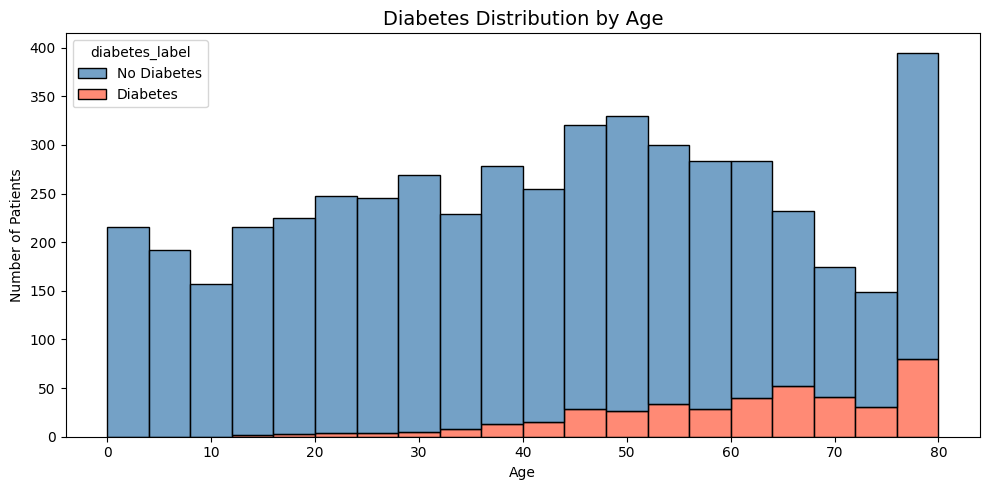

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plot 1: Age distribution by diabetes status
plt.figure(figsize=(10, 5))
sns.histplot(
    data=pdf,
    x="age",
    hue="diabetes_label",
    multiple="stack",
    bins=20,
    palette={"No Diabetes": "steelblue", "Diabetes": "tomato"}
)
plt.title("Diabetes Distribution by Age", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

C:\Users\poude\AppData\Local\Temp\ipykernel_32668\3330591847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


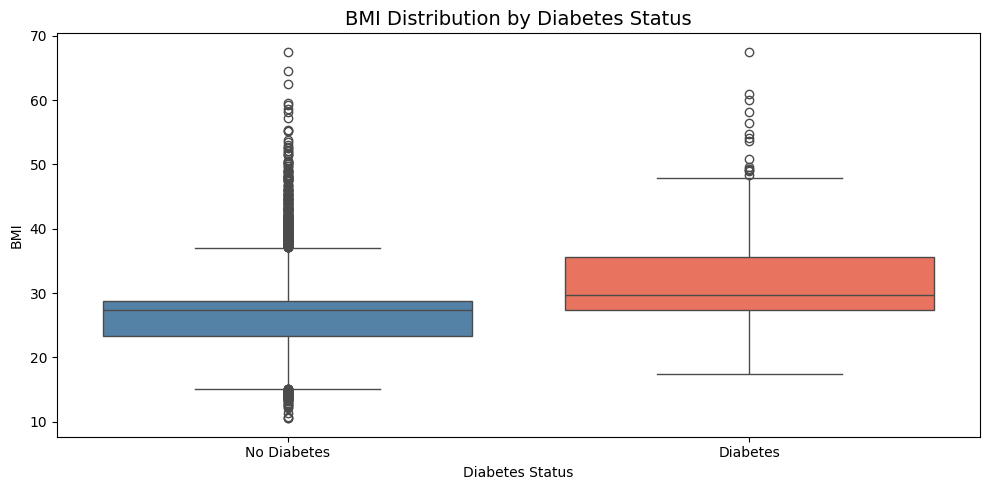

In [ ]:
# Plot 2: BMI distribution by diabetes status
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=pdf,
    x="diabetes_label",
    y="bmi",
    palette={"No Diabetes": "steelblue", "Diabetes": "tomato"}
)
plt.title("BMI Distribution by Diabetes Status", fontsize=14)
plt.xlabel("Diabetes Status")
plt.ylabel("BMI")
plt.tight_layout()
plt.show()

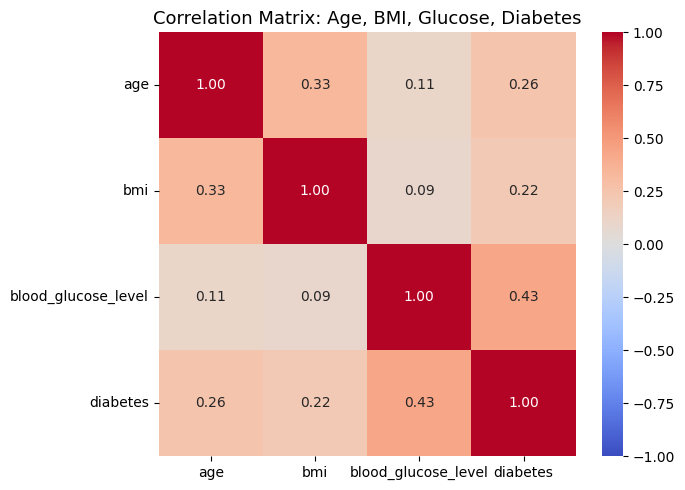

In [ ]:
# Plot 3: Correlation heatmap
numeric_cols = pdf[["age", "bmi", "blood_glucose_level", "diabetes"]]

plt.figure(figsize=(7, 5))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1
)
plt.title("Correlation Matrix: Age, BMI, Glucose, Diabetes", fontsize=13)
plt.tight_layout()
plt.show()

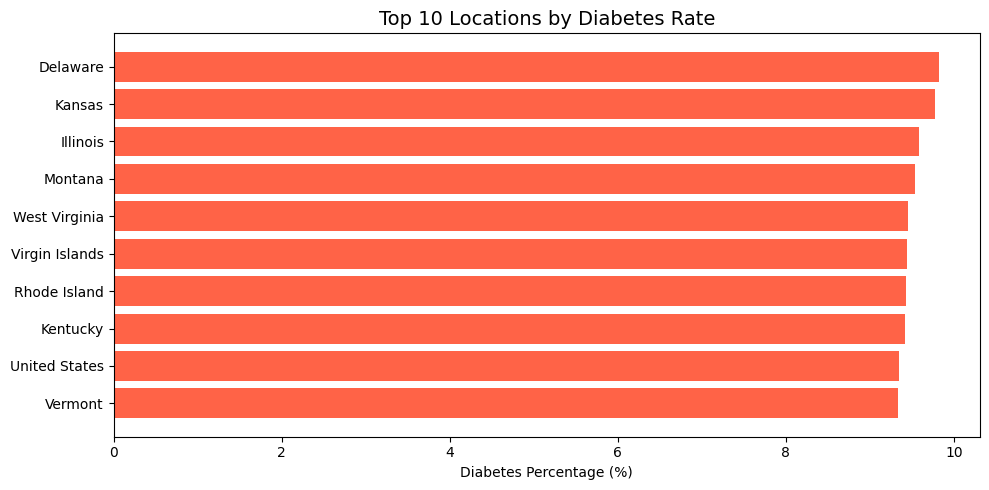

In [ ]:
# Plot 4: Diabetes rate from Spark SQL results
results_pdf = analysis_results.toPandas().head(10)

plt.figure(figsize=(10, 5))
plt.barh(
    results_pdf["location"],
    results_pdf["diabetes_percentage"],
    color="tomato"
)
plt.xlabel("Diabetes Percentage (%)")
plt.title("Top 10 Locations by Diabetes Rate", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Clean up: stop Spark session when done
spark.stop()
print("Spark session stopped. Pipeline complete!")

Spark session stopped. Pipeline complete!
